# Time-Series Foundation Model — Chronos Embeddings

Uses **Chronos-T5** (Amazon) to compute a single embedding per ICU patient:

1. Separate the triplet data into 40 individual univariate channels (one per variable)
2. Encode each channel with Chronos' encoder → mean-pool over time → one vector per channel
3. Average across all observed channels → one **(D_MODEL,)** patient embedding
4. Train a linear probe on set-A, evaluate on set-C
5. Visualise with t-SNE and UMAP

> **Model**: `amazon/chronos-t5-small` (d_model=512). Change `MODEL_NAME` to `tiny` / `base` / `large` as needed.

In [1]:
import os
import sys


IS_COLAB = 'google.colab' in sys.modules or 'COLAB_RELEASE_TAG' in os.environ

if IS_COLAB:
    print('Running on Colab')
    from google.colab import drive
    drive.mount('/content/drive')
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'chronos-forecasting'], check=True)
else:
    print('Running locally')

Running on Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1 — Imports & constants

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import umap

from chronos import ChronosPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import normalize as sk_normalize


TRIPLET_VARS = [
    'Albumin', 'ALP', 'ALT', 'AST', 'Bilirubin', 'BUN', 'Cholesterol',
    'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT',
    'HR', 'K', 'Lactate', 'Mg', 'MAP', 'MechVent', 'Na', 'NIDiasABP',
    'NIMAP', 'NISysABP', 'PaCO2', 'PaO2', 'pH', 'Platelets', 'RespRate',
    'SaO2', 'SysABP', 'Temp', 'TroponinI', 'TroponinT', 'Urine', 'WBC',
    'age', 'height_cm', 'weight_kg', 'gender',
]
N_VARS = len(TRIPLET_VARS)

DATA_DIR   = (
    './drive/MyDrive/data' if IS_COLAB
    else '/workspaces/intensive_care_time_series_modeling_for_mortality_predictions/data'
)
MODEL_NAME = 'amazon/chronos-t5-small'
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'DATA_DIR : {DATA_DIR}')
print(f'Device   : {DEVICE}')
print(f'Model    : {MODEL_NAME}')

DATA_DIR : ./drive/MyDrive/data
Device   : cuda
Model    : amazon/chronos-t5-small


## 2 — Load normalised triplet data

In [3]:
df_a = pd.read_parquet(os.path.join(DATA_DIR, 'set_a_triplet.parquet'))
df_b = pd.read_parquet(os.path.join(DATA_DIR, 'set_b_triplet.parquet'))
df_c = pd.read_parquet(os.path.join(DATA_DIR, 'set_c_triplet.parquet'))

for name, df in [('set-a', df_a), ('set-b', df_b), ('set-c', df_c)]:
    n_pat  = df['PatientID'].nunique()
    mort   = df.groupby('PatientID')['in_hospital_death'].first().mean()
    print(f'{name}: {n_pat} patients, {len(df):,} events, {mort:.2%} mortality')

set-a: 4000 patients, 1,618,740 events, 13.85% mortality
set-b: 4000 patients, 1,622,803 events, 14.20% mortality
set-c: 4000 patients, 1,623,953 events, 14.62% mortality


## 3 — Load Chronos

In [ ]:
pipeline = ChronosPipeline.from_pretrained(
    MODEL_NAME,
    device_map=DEVICE,
    torch_dtype=torch.bfloat16,
)
pipeline.model.eval()

_dummy_emb, _ = pipeline.embed(torch.zeros(1, 10))
D_MODEL = _dummy_emb.shape[-1]
print(f'Loaded {MODEL_NAME}  |  d_model={D_MODEL}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/185M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

Loaded amazon/chronos-t5-small  |  d_model=512


## 4 — Extract embeddings

**Aggregation scheme:** for each patient, each observed variable is treated as a separate univariate time series. Chronos encodes it into a sequence of hidden states; we mean-pool over time to get one vector per channel, then average across all observed channels to get a single patient embedding.

In [5]:
def embed_split(df: pd.DataFrame, desc: str = '') -> tuple[np.ndarray, np.ndarray]:
    """
    Compute one embedding vector per patient from the triplet DataFrame.

    Aggregation scheme
    ------------------
    For each patient:
      1. Separate events by variable (variable_idx 0–39).
      2. For each observed variable, pass its value sequence (sorted by t)
         to Chronos' encoder → mean-pool the hidden states over time
         → one (D_MODEL,) vector per variable.
      3. Average across all observed variable embeddings
         → one (D_MODEL,) patient embedding.

    Patients with no measurements get a zero vector.
    """
    pids    = df['PatientID'].unique()
    grouped = dict(df.groupby('PatientID'))
    embs    = np.zeros((len(pids), D_MODEL), dtype=np.float32)
    labels  = np.zeros(len(pids), dtype=int)

    for i, pid in enumerate(pids):
        grp   = grouped[pid].sort_values('t')
        labels[i] = int(grp['in_hospital_death'].iloc[0])

        series_list: list[torch.Tensor] = []
        for var_idx in range(N_VARS):
            vals = grp.loc[grp['variable_idx'] == var_idx, 'v'].to_numpy(dtype=np.float32)
            if len(vals) > 0:
                series_list.append(torch.from_numpy(vals))

        if not series_list:
            continue  # leave as zero vector

        with torch.no_grad():
            embedding, _ = pipeline.embed(series_list)

        var_embs   = embedding.float().mean(dim=1)   # (n_vars, D_MODEL)
        embs[i]    = var_embs.mean(dim=0).cpu().numpy()  # (D_MODEL,)

        if (i + 1) % 200 == 0 or (i + 1) == len(pids):
            print(f'  [{desc}] {i+1}/{len(pids)}')

    return embs, labels


print('Embedding set-a ...')
emb_train, lbl_train = embed_split(df_a, 'set-a')
print(f'set-a: {emb_train.shape}')

print('Embedding set-b ...')
emb_val, lbl_val = embed_split(df_b, 'set-b')
print(f'set-b: {emb_val.shape}')

print('Embedding set-c ...')
emb_test, lbl_test = embed_split(df_c, 'set-c')
print(f'set-c: {emb_test.shape}')

Embedding set-a ...
  [set-a] 200/4000
  [set-a] 400/4000
  [set-a] 600/4000
  [set-a] 800/4000
  [set-a] 1000/4000
  [set-a] 1200/4000
  [set-a] 1400/4000
  [set-a] 1600/4000
  [set-a] 1800/4000
  [set-a] 2000/4000
  [set-a] 2200/4000
  [set-a] 2400/4000
  [set-a] 2600/4000
  [set-a] 2800/4000
  [set-a] 3000/4000
  [set-a] 3200/4000
  [set-a] 3400/4000
  [set-a] 3600/4000
  [set-a] 3800/4000
  [set-a] 4000/4000
set-a: (4000, 512)
Embedding set-b ...
  [set-b] 200/4000
  [set-b] 400/4000
  [set-b] 600/4000
  [set-b] 800/4000
  [set-b] 1000/4000
  [set-b] 1200/4000
  [set-b] 1400/4000
  [set-b] 1600/4000
  [set-b] 1800/4000
  [set-b] 2000/4000
  [set-b] 2200/4000
  [set-b] 2400/4000
  [set-b] 2600/4000
  [set-b] 2800/4000
  [set-b] 3000/4000
  [set-b] 3200/4000
  [set-b] 3400/4000
  [set-b] 3600/4000
  [set-b] 3800/4000
  [set-b] 4000/4000
set-b: (4000, 512)
Embedding set-c ...
  [set-c] 200/4000
  [set-c] 400/4000
  [set-c] 600/4000
  [set-c] 800/4000
  [set-c] 1000/4000
  [set-c] 1200

## 5 — Linear probe (set-A → set-C)

In [6]:
for name, emb in [('train', emb_train), ('val', emb_val), ('test', emb_test)]:
    n_bad = np.isnan(emb).any(axis=1).sum()
    if n_bad: print(f'{name}: {n_bad} NaN rows → replacing with 0')

emb_train = np.nan_to_num(emb_train, nan=0.0)
emb_val   = np.nan_to_num(emb_val,   nan=0.0)
emb_test  = np.nan_to_num(emb_test,  nan=0.0)

emb_train_n = sk_normalize(emb_train, norm='l2')
emb_val_n   = sk_normalize(emb_val,   norm='l2')
emb_test_n  = sk_normalize(emb_test,  norm='l2')

probe = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
probe.fit(emb_train_n, lbl_train)

prob_val  = probe.predict_proba(emb_val_n)[:, 1]
prob_test = probe.predict_proba(emb_test_n)[:, 1]

val_auroc  = roc_auc_score(lbl_val,  prob_val)
val_auprc  = average_precision_score(lbl_val,  prob_val)
test_auroc = roc_auc_score(lbl_test, prob_test)
test_auprc = average_precision_score(lbl_test, prob_test)

print('=' * 52)
print(f'  Chronos ({MODEL_NAME}) linear probe')
print('=' * 52)
print(f'  Val  set-B  AuROC={val_auroc:.4f}  AuPRC={val_auprc:.4f}')
print(f'  Test set-C  AuROC={test_auroc:.4f}  AuPRC={test_auprc:.4f}')
print('=' * 52)

  Chronos (amazon/chronos-t5-small) linear probe
  Val  set-B  AuROC=0.7130  AuPRC=0.3055
  Test set-C  AuROC=0.7225  AuPRC=0.3123


## 6 — t-SNE

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


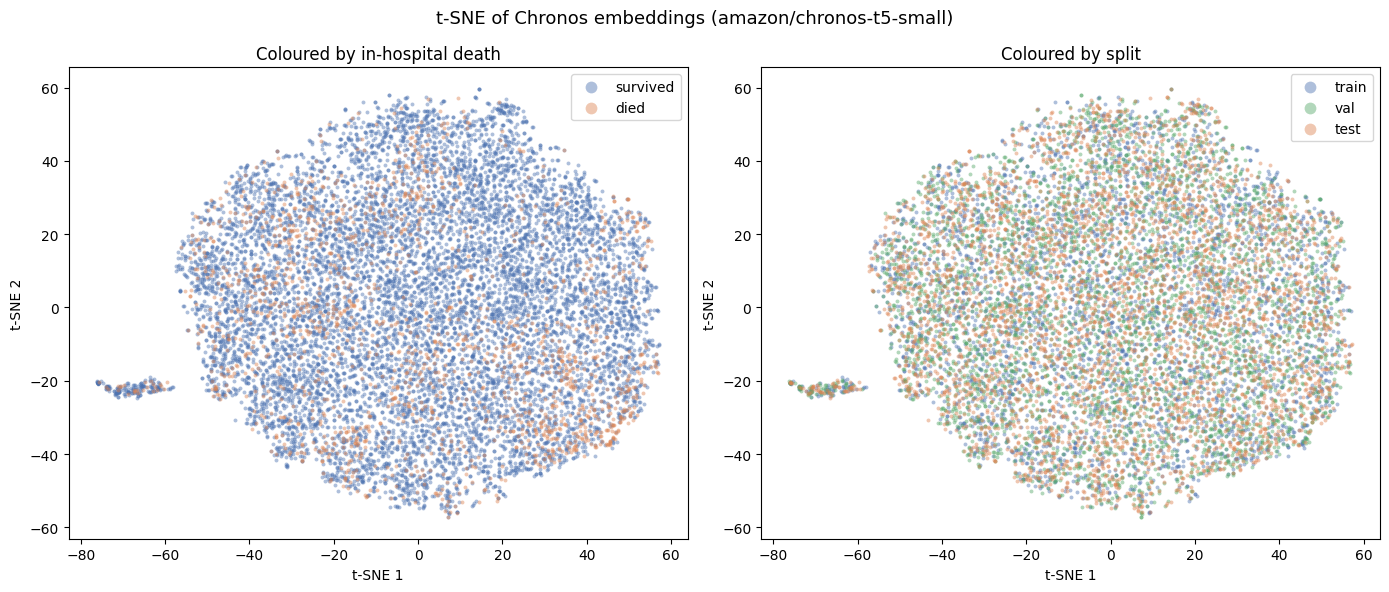

In [7]:
emb_all   = np.vstack([emb_train, emb_val, emb_test])
lbl_all   = np.concatenate([lbl_train, lbl_val, lbl_test])
split_all = np.array(
    ['train'] * len(lbl_train) +
    ['val']   * len(lbl_val)   +
    ['test']  * len(lbl_test)
)
split_colors = {'train': '#4c72b0', 'val': '#55a868', 'test': '#dd8452'}

tsne      = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000)
emb2_tsne = tsne.fit_transform(sk_normalize(emb_all, norm='l2'))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f't-SNE of Chronos embeddings ({MODEL_NAME})', fontsize=13)

ax = axes[0]
for lbl, name, c in [(0, 'survived', '#4c72b0'), (1, 'died', '#dd8452')]:
    mask = lbl_all == lbl
    ax.scatter(emb2_tsne[mask, 0], emb2_tsne[mask, 1],
               c=c, label=name, alpha=0.45, s=8, linewidths=0)
ax.set_title('Coloured by in-hospital death')
ax.legend(markerscale=3)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')

ax = axes[1]
for sp, c in split_colors.items():
    mask = split_all == sp
    ax.scatter(emb2_tsne[mask, 0], emb2_tsne[mask, 1],
               c=c, label=sp, alpha=0.45, s=8, linewidths=0)
ax.set_title('Coloured by split')
ax.legend(markerscale=3)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')

plt.tight_layout(); plt.show()

## 7 — UMAP

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


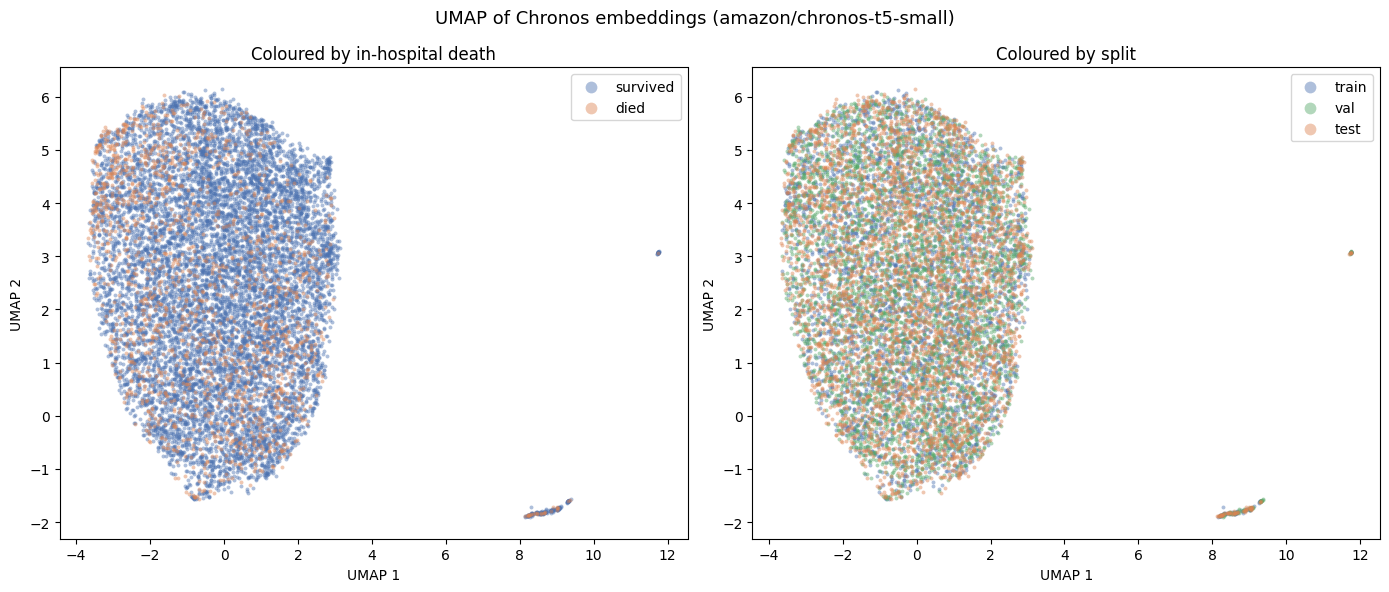

In [8]:
reducer   = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
emb2_umap = reducer.fit_transform(sk_normalize(emb_all, norm='l2'))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'UMAP of Chronos embeddings ({MODEL_NAME})', fontsize=13)

ax = axes[0]
for lbl, name, c in [(0, 'survived', '#4c72b0'), (1, 'died', '#dd8452')]:
    mask = lbl_all == lbl
    ax.scatter(emb2_umap[mask, 0], emb2_umap[mask, 1],
               c=c, label=name, alpha=0.45, s=8, linewidths=0)
ax.set_title('Coloured by in-hospital death')
ax.legend(markerscale=3)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

ax = axes[1]
for sp, c in split_colors.items():
    mask = split_all == sp
    ax.scatter(emb2_umap[mask, 0], emb2_umap[mask, 1],
               c=c, label=sp, alpha=0.45, s=8, linewidths=0)
ax.set_title('Coloured by split')
ax.legend(markerscale=3)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

plt.tight_layout(); plt.show()